In [2]:
import os
import datajoint as dj
import numpy as np
import pandas as pd

dj.config.load("dj_local_conf.json")  # load config for database connection info

import spyglass.common as sgc
import spyglass.position.v1 as sgp
import spyglass.lfp.analysis.v1 as lfp_analysis
from spyglass.lfp import LFPOutput
import spyglass.lfp as sglfp
from spyglass.position import PositionOutput
import spyglass.ripple.v1 as sgrip
import spyglass.ripple.v1 as sgr

import warnings

warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)

[2026-07-06 16:37:09,916][INFO]: DataJoint is configured from /home/dmrodriguez/mPFC-opto/notebooks/dj_local_conf.json


In [3]:
sglfp.v1.LFPV1() & {'nwb_file_name': 'Charlie20260223_.nwb'}

nwb_file_name name of the NWB file,lfp_electrode_group_name the name of this group of electrodes,target_interval_list_name descriptive name of this interval list,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,analysis_file_name name of the file,interval_list_name descriptive name of this interval list,lfp_object_id the NWB object ID for loading this object from the file,"lfp_sampling_rate the sampling rate, in HZ"
Charlie20260223_.nwb,EMG Channels,01_s1,EMG 300-600 DMR,29999,Charlie20260223_7X6ASGDHI9.nwb,lfp_EMG Channels_01_s1_valid times,64fb46a2-0aef-48d0-a76e-0cb704e54932,2142.0
Charlie20260223_.nwb,EMG Channels,03_s2,EMG 300-600 DMR,29999,Charlie20260223_075H0U2Q8U.nwb,lfp_EMG Channels_03_s2_valid times,b15dfa37-bded-4b2b-a7ff-5e99e5504cb0,2142.0
Charlie20260223_.nwb,EMG Channels,05_s3,EMG 300-600 DMR,29999,Charlie20260223_R3RWQJ4N42.nwb,lfp_EMG Channels_05_s3_valid times,723121ba-fe5f-46a1-b651-fbb4d22cd0e4,2142.0
Charlie20260223_.nwb,EMG Channels,07_s4,EMG 300-600 DMR,29999,Charlie20260223_FZZ1BTS762.nwb,lfp_EMG Channels_07_s4_valid times,bfc85ac1-1f1b-4894-9c47-ba40392f589f,2142.0
Charlie20260223_.nwb,EMG Channels,09_s5,EMG 300-600 DMR,29999,Charlie20260223_KLPE7UEHYJ.nwb,lfp_EMG Channels_09_s5_valid times,6d2adc17-e5af-4f9c-bf5a-8295fa106936,2142.0
Charlie20260223_.nwb,EMG Channels,11_s6,EMG 300-600 DMR,29999,Charlie20260223_E5B3OLIDRF.nwb,lfp_EMG Channels_11_s6_valid times,fa2db843-8af1-4745-9d17-127f7f74c7f9,2142.0
Charlie20260223_.nwb,left and right mPFC,01_s1,LFP 0-400 Hz DMR,29999,Charlie20260223_JVOA9CBV4X.nwb,lfp_left and right mPFC_01_s1_valid times,499d5885-0f2a-4452-b43e-1c9cc45fdee9,1034.0
Charlie20260223_.nwb,left and right mPFC,03_s2,LFP 0-400 Hz DMR,29999,Charlie20260223_I27WNOT266.nwb,lfp_left and right mPFC_03_s2_valid times,1070f1af-94ee-40f1-96dd-669014a371ae,1034.0
Charlie20260223_.nwb,left and right mPFC,05_s3,LFP 0-400 Hz DMR,29999,Charlie20260223_TKA6XYFUJG.nwb,lfp_left and right mPFC_05_s3_valid times,5144a76a-1432-4e1f-af59-a55e4aedfc57,1034.0
Charlie20260223_.nwb,left and right mPFC,07_s4,LFP 0-400 Hz DMR,29999,Charlie20260223_9WX7FHU0ZZ.nwb,lfp_left and right mPFC_07_s4_valid times,e5e8b381-a459-4a5c-b174-807a4d946d8f,1034.0


In [4]:
nwb_file_name = 'Charlie20260224_.nwb'

In [5]:
lfp_electrode_group_name = "Left and Right CA1 Hippocampus"
lfp_eg_key = {
    "nwb_file_name":nwb_file_name,
    "lfp_electrode_group_name": lfp_electrode_group_name,
}


In [6]:
LFPOutput.LFPV1() << {"nwb_file_name": nwb_file_name}

[16:37:13][WARNING] Spyglass: Restriction valid for this table. Using as is.


merge_id,nwb_file_name name of the NWB file,lfp_electrode_group_name the name of this group of electrodes,target_interval_list_name descriptive name of this interval list,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter
02f37c6f-90c5-6c9a-ae99-ca2f4b4a715c,Charlie20260224_.nwb,left and right mPFC,07_s4,LFP 0-400 Hz DMR,29999
228b08c8-fc93-e6bf-b494-30065b7600c4,Charlie20260224_.nwb,left hippocampus good,02_r1,LFP 0-400 Hz DMR,29999
24f0a7f3-9d46-686d-4021-11011327c104,Charlie20260224_.nwb,EMG channels,05_s3,EMG 300-600 DMR,29999
25f31479-4a6e-ec3e-3d0f-0ed5b98c117e,Charlie20260224_.nwb,left and right mPFC,05_s3,LFP 0-400 Hz DMR,29999
29b695ff-cdb9-43b0-022f-f21a6c35de53,Charlie20260224_.nwb,left hippocampus good,11_s6,LFP 0-400 Hz DMR,29999
2a8edc62-0536-ae5f-da09-49546ebd3168,Charlie20260224_.nwb,left and right mPFC,09_s5,LFP 0-400 Hz DMR,29999
35b172d5-1c99-e7a1-fd28-386d5b1023af,Charlie20260224_.nwb,left hippocampus good,09_s5,LFP 0-400 Hz DMR,29999
39059d0b-24c0-1062-502c-0675ca0686c0,Charlie20260224_.nwb,left hippocampus good,05_s3,LFP 0-400 Hz DMR,29999
4e7c9864-0857-9413-e633-d1fd63babcf2,Charlie20260224_.nwb,left hippocampus good,01_s1,LFP 0-400 Hz DMR,29999
6b1b0e85-0cde-2887-6c69-49b5734233b0,Charlie20260224_.nwb,left hippocampus good,04_r2,LFP 0-400 Hz DMR,29999


In [7]:
sgrip.RippleTimesV1() & {"nwb_file_name": nwb_file_name}


lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,group_name,ripple_param_name a name for this set of parameters,pos_merge_id,analysis_file_name name of the file,ripple_times_object_id
228b08c8-fc93-e6bf-b494-30065b7600c4,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,02_r1,1034,Ripple Detection Channels,default_trodes,7db61d2c-d04a-ebb4-1535-68c5564e0dc9,Charlie20260224_RBDDK4MQU2.nwb,2caef7fe-8a33-4387-b3ae-a85ea7ebffbc
35b172d5-1c99-e7a1-fd28-386d5b1023af,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,09_s5,1034,Ripple Detection Channels,denisse_1.5sd,883fd450-5f38-b221-fd05-ed9e894b3eae,Charlie20260224_UT02AHIUDB.nwb,228e5c2b-d284-469c-adc1-5a94b3cb7a4f
39059d0b-24c0-1062-502c-0675ca0686c0,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,05_s3,1034,Ripple Detection Channels,default_trodes,365c2f51-d0f4-4e3b-1aa8-f7a143dd2d8e,Charlie20260224_3EE5LQVY5U.nwb,5430fc82-309e-42ad-b9b0-20b96ac4b966
39059d0b-24c0-1062-502c-0675ca0686c0,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,05_s3,1034,Ripple Detection Channels,denisse_1.5sd,365c2f51-d0f4-4e3b-1aa8-f7a143dd2d8e,Charlie20260224_BCX72DXW4F.nwb,e2318ca9-7ede-48bf-aad6-80a5b76757f2
4e7c9864-0857-9413-e633-d1fd63babcf2,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,01_s1,1034,Ripple Detection Channels,denisse_1.5sd,6905d6d0-b0e3-aca0-2177-49745731b83f,Charlie20260224_H2MMJ2ZE8C.nwb,c477ebb3-aa01-4cd2-b125-a4f06d9737ad
6b1b0e85-0cde-2887-6c69-49b5734233b0,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,04_r2,1034,Ripple Detection Channels,default_trodes,61e73b70-789f-06ae-b67d-54eb473844b8,Charlie20260224_12ZL3A9SFK.nwb,5fcd52b6-bc34-414b-9100-317be46d644b
a8562a11-72ec-8bfc-be45-6e82a3454162,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,03_s2,1034,Ripple Detection Channels,denisse_1.5sd,0046e095-0a0b-d992-ad00-5b2ed0e6d7c0,Charlie20260224_WQ1D7G72M5.nwb,e0d7bf94-df66-47d3-9c30-f42971f10286
b8a8ed47-07d8-d735-d0b4-d4354a5dff08,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,07_s4,1034,Ripple Detection Channels,denisse_1.5sd,a93f4a92-930f-d7a5-7a09-15f399757d21,Charlie20260224_QHEZVFVOZD.nwb,114c89b6-775c-4ad6-a67f-0deeed6b2219


In [30]:
ripple_times = (sgrip.RippleTimesV1() & {'lfp_merge_id': '39059d0b-24c0-1062-502c-0675ca0686c0',
                                         'ripple_param_name': 'default_trodes'}).fetch1_dataframe()
ripple_times

/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
ndx-pose - cached version: 0.2.0, loaded version: 0.3.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/devices/MarketTech LuxX+ Red/model
  warnings.warn('Path to Group altered/broken at ' + os.path.join(h5obj.name, k), BrokenLinkWarning)
/home/dmrodriguez/miniforge3/envs/spyglass_py310_new/lib/python3.10/site-packages/hdmf/backends/hdf5/h5tools.py:620: BrokenLinkWarning: Path to Group altered/broken at /general/dev

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
id,,,,,,,,,,,,,,,,
0,1.771962e+09,1.771962e+09,0.087969,3.338891,1.519363,1.097073,3.967477,0.024825,0.135100,0.357446,0.959888,0.589643,0.959888,0.589643,0.725826,0.746011
1,1.771962e+09,1.771962e+09,0.060901,3.428816,1.992888,1.620669,4.584951,0.005475,0.123272,0.399770,2.676255,3.280816,3.280816,2.676255,3.082196,3.044299
2,1.771962e+09,1.771962e+09,0.086035,3.591680,1.588139,0.963636,4.423788,0.021022,0.138146,0.410300,0.124368,0.160842,0.160842,0.104677,0.113106,0.118364
3,1.771962e+09,1.771962e+09,0.147903,3.192727,1.170341,0.701932,3.873851,0.072858,0.174149,0.376563,3.196441,1.302038,3.196441,1.302038,2.177962,2.212899
4,1.771962e+09,1.771962e+09,0.081202,3.652040,1.916459,1.285347,4.420072,0.000591,0.157442,0.449403,0.286550,0.380612,0.380612,0.281521,0.300932,0.312380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3526,1.771965e+09,1.771965e+09,0.164337,2.917561,1.656756,1.499201,4.809715,0.005329,0.273840,0.708319,1.251600,0.549871,1.251600,0.193128,0.538646,0.632723
3527,1.771965e+09,1.771965e+09,0.205904,2.197327,0.973631,0.760505,4.014757,0.038367,0.201377,0.321306,0.956219,0.302768,0.956219,0.302768,0.666839,0.650076
3528,1.771965e+09,1.771965e+09,0.211704,2.223592,1.446211,1.281564,3.858265,0.021237,0.307528,0.643393,2.130707,1.863898,3.157086,1.829374,2.682989,2.598260


In [31]:
np.mean(ripple_times['duration'])

0.08887674017824893

In [32]:
np.median(ripple_times['duration'])

0.07636809349060059

In [33]:
np.mean(ripple_times['mean_zscore'])

1.8076075160249792

In [34]:
np.median(ripple_times['mean_zscore'])

1.7759888736268834

In [35]:
import pynwb
import spyglass.common as sgc

In [36]:
io = pynwb.NWBHDF5IO("/stelmo/nwb/raw/Charlie20260224.nwb", mode="r")
nwbf = io.read()

In [37]:

epoch_start_time, epoch_stop_time, epoch_name = nwbf.intervals['epochs'][4].to_numpy()[0]

laser_data = nwbf.processing['behavior'].data_interfaces['behavioral_events'].time_series['Laser'].data[:]
laser_timestamps = nwbf.processing['behavior'].data_interfaces['behavioral_events'].time_series['Laser'].timestamps[:]

# Restrict to epoch
mask = (laser_timestamps > epoch_start_time) & (laser_timestamps <= epoch_stop_time)

laser_data_epoch = laser_data[mask]
laser_timestamps_epoch = laser_timestamps[mask]

# Ensure clean start
laser_data_epoch[0] = 0

# --- KEY STEP: only look at ON samples ---
laser_on_times_epoch = laser_timestamps_epoch[laser_data_epoch == 1]

# --- Detect first pulse of each train ---
first_laser_on_times = laser_on_times_epoch[
    np.insert(np.diff(laser_on_times_epoch) > 0.01, 0, True)]

In [16]:

df = pd.DataFrame({"timestamp": first_laser_on_times})
df

,timestamp
0,1.771962e+09
1,1.771962e+09
2,1.771962e+09
3,1.771962e+09
4,1.771962e+09
...,...
3196,1.771965e+09
3197,1.771965e+09
3198,1.771965e+09
3199,1.771965e+09


In [17]:
from spyglass.lfp.analysis.v1 import lfp_band

In [18]:
lfp_band.LFPBandV1() & {'nwb_file_name': 'Charlie20260224_.nwb'}

lfp_merge_id,filter_name descriptive name of this filter,filter_sampling_rate sampling rate for this filter,nwb_file_name name of the NWB file,target_interval_list_name descriptive name of this interval list,lfp_band_sampling_rate the sampling rate for this band,analysis_file_name name of the file,interval_list_name descriptive name of this interval list,lfp_band_object_id the NWB object ID for loading this object from the file
02f37c6f-90c5-6c9a-ae99-ca2f4b4a715c,Delta 0.5-4 Hz DMR,1034,Charlie20260224_.nwb,07_s4,1034,Charlie20260224_H25XAKHS3U.nwb,07_s4 lfp band 1034Hz,79393edf-c571-492f-9005-0c6b7a43b5ff
02f37c6f-90c5-6c9a-ae99-ca2f4b4a715c,Theta 5-11 Hz DMR,1034,Charlie20260224_.nwb,07_s4,1034,Charlie20260224_4MUM9E5KBA.nwb,07_s4 lfp band 1034Hz,0515857e-13a9-4172-a151-7c4c6d704c4d
228b08c8-fc93-e6bf-b494-30065b7600c4,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,02_r1,1034,Charlie20260224_S4WYXC3DRZ.nwb,02_r1 lfp band 1034Hz,1287b998-0123-44d9-b7f8-e0b08c0352c7
228b08c8-fc93-e6bf-b494-30065b7600c4,Theta 5-11 Hz DMR,1034,Charlie20260224_.nwb,02_r1,1034,Charlie20260224_1GT48BQBZ4.nwb,02_r1 lfp band 1034Hz,eedfe6ad-ff80-4a18-be3b-9c905b642af2
25f31479-4a6e-ec3e-3d0f-0ed5b98c117e,Delta 0.5-4 Hz DMR,1034,Charlie20260224_.nwb,05_s3,1034,Charlie20260224_56H8YHJ6U7.nwb,05_s3 lfp band 1034Hz,e29d9a47-3bb3-49ad-bfb5-74c8fc5b7d6a
25f31479-4a6e-ec3e-3d0f-0ed5b98c117e,Theta 5-11 Hz DMR,1034,Charlie20260224_.nwb,05_s3,1034,Charlie20260224_0Y579KEJI1.nwb,05_s3 lfp band 1034Hz,9993a22c-4070-4087-af8f-68d8906d7c51
29b695ff-cdb9-43b0-022f-f21a6c35de53,Delta 0.5-4 Hz DMR,1034,Charlie20260224_.nwb,11_s6,1034,Charlie20260224_P3Q71U5GT3.nwb,11_s6 lfp band 1034Hz,90e742db-b1bf-4853-8f4a-84dfe6442737
29b695ff-cdb9-43b0-022f-f21a6c35de53,Ripple 150-250 Hz DMR,1034,Charlie20260224_.nwb,11_s6,1034,Charlie20260224_W32DW1Z9PW.nwb,11_s6 lfp band 1034Hz,3777c792-a6ae-452a-bb3c-5e92ede8923f
29b695ff-cdb9-43b0-022f-f21a6c35de53,Theta 5-11 Hz DMR,1034,Charlie20260224_.nwb,11_s6,1034,Charlie20260224_USIYZU50H4.nwb,11_s6 lfp band 1034Hz,84336bb0-7c9f-443f-a3b8-b1c319a80061
2a8edc62-0536-ae5f-da09-49546ebd3168,Delta 0.5-4 Hz DMR,1034,Charlie20260224_.nwb,09_s5,1034,Charlie20260224_2EQTMPPUL7.nwb,09_s5 lfp band 1034Hz,32cbb080-8f4d-438e-9c0a-43771c14ccab


Text(0, 0.5, 'Voltage (uV)')

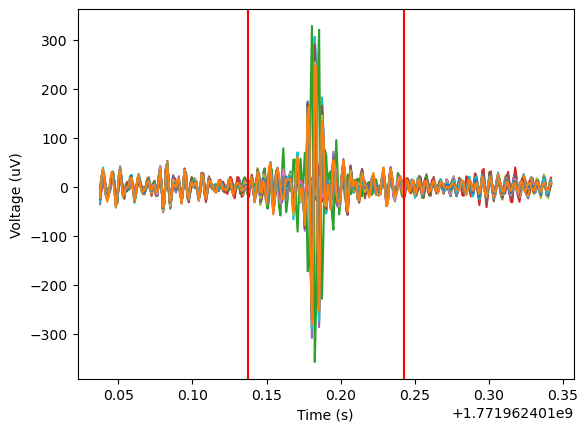

In [68]:
import matplotlib.pyplot as plt
lfp_band_key =  {'nwb_file_name': 'Charlie20260224_.nwb',
                                          'target_interval_list_name': '05_s3',
                                          'filter_name': 'Ripple 150-250 Hz DMR',
                                    }

ripple_band_df = (lfp_band.LFPBandV1() & {'nwb_file_name': 'Charlie20260224_.nwb',
                                          'filter_name': 'Ripple 150-250 Hz DMR',
                                          'target_interval_list_name': '05_s3'}).fetch1_dataframe()

window = 0.1
i = 10 #[-10, 505, 601, 610, 200]
ripple_start = ripple_times.iloc[i].start_time
ripple_end = ripple_times.iloc[i].end_time
plt.plot(
    ripple_band_df.loc[ripple_start - window : ripple_end + window].index,
    ripple_band_df.loc[ripple_start - window : ripple_end + window].iloc[
        :, ::2
    ],
)
plt.axvline(ripple_start, color="r")
plt.axvline(ripple_end, color="r")

plt.xlabel("Time (s)")
plt.ylabel("Voltage (uV)")

In [69]:
subset = ripple_band_df.loc[ripple_start - window : ripple_end + window]
print(subset.shape)

(316, 44)


In [70]:
import pandas as pd

# Assume df['timestamps'] holds your pulse times (sorted, in seconds)
timestamps = df['timestamp'].sort_values().reset_index(drop=True)

# Compute differences between consecutive pulses
dt = timestamps.diff()

# A "new burst" starts when the gap is bigger than ~3 ms
gap_threshold = 0.01  # seconds (3.5 ms to be safe)
burst_id = (dt > gap_threshold).cumsum()

# Group by burst and count how many pulses in each
burst_counts = timestamps.groupby(burst_id).count()

print(burst_counts)


timestamp
0       1
1       1
2       1
3       1
4       1
       ..
3196    1
3197    1
3198    1
3199    1
3200    1
Name: timestamp, Length: 3201, dtype: int64


In [71]:
import matplotlib.pyplot as plt
import numpy as np

window = 0.100  # 100 ms
burst_size = 40
delays = []

for start in ripple_times['start_time']:
    timestamps_in_window = df[
        (df['timestamp'] >= start) & (df['timestamp'] <= start + window)
    ]['timestamp']
    if len(timestamps_in_window) > 0:
        laser_start = timestamps_in_window.values[0]
        delay = laser_start - start
        delays.append(delay)
delays = np.array(delays)


In [72]:
import matplotlib.pyplot as plt
import numpy as np

window = 0.1
delays = []
for start in ripple_times['start_time']:
    time_window = ripple_band_df.loc[start: start + window]

    timestamps_in_window = df[
        (df['timestamp'] >= start) & (df['timestamp'] <= start+ window)
    ]['timestamp']

    # Only keep every other timestamp
    timestamps_in_window = timestamps_in_window.iloc[::40]
    delays.append((timestamps_in_window - start))


In [73]:
timestamps_in_window

Series([], Name: timestamp, dtype: float64)

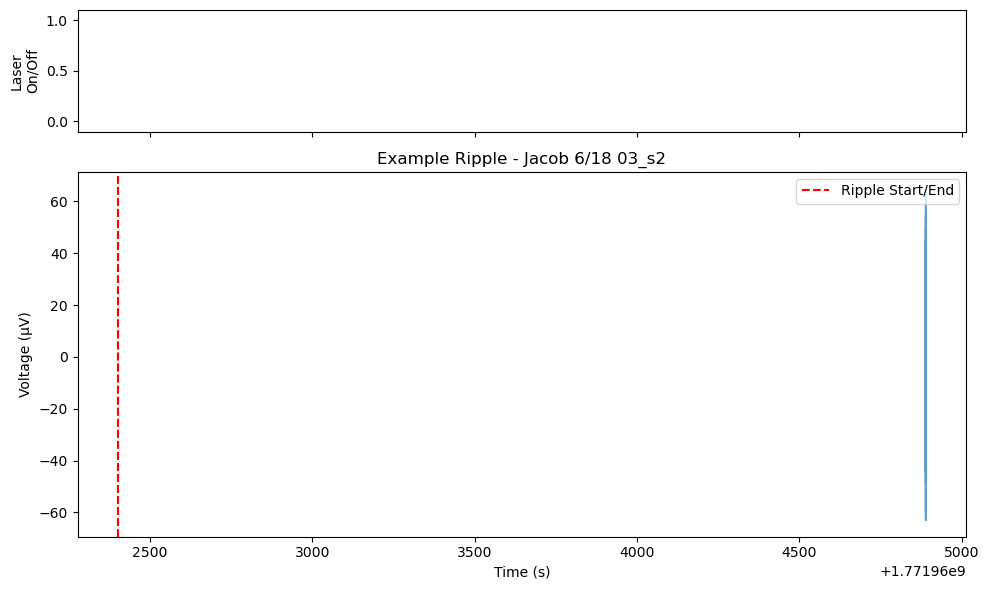

In [74]:
# --- Binary 0/1 trace ---
binary_trace = np.zeros(len(time_window.index))
for ts in timestamps_in_window:
    idx = time_window.index.get_indexer([ts], method="nearest")[0]
    if idx != -1:
        binary_trace[idx] = 1

# --- Create subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6),
                               sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Top subplot
ax1.step(time_window.index, binary_trace, where="post", color="blue")
ax1.set_ylabel("Laser\nOn/Off")
ax1.set_ylim(-0.1, 1.1)

# Bottom subplot
ax2.plot(time_window.index, time_window.iloc[:, 0], alpha=0.7)
ax2.axvline(ripple_start, color="r", linestyle="--", label="Ripple Start/End")
ax2.axvline(ripple_end, color="r", linestyle="--")

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (µV)")
ax2.set_title("Example Ripple - Jacob 6/18 03_s2")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


/tmp/ipykernel_801466/3086784140.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right")


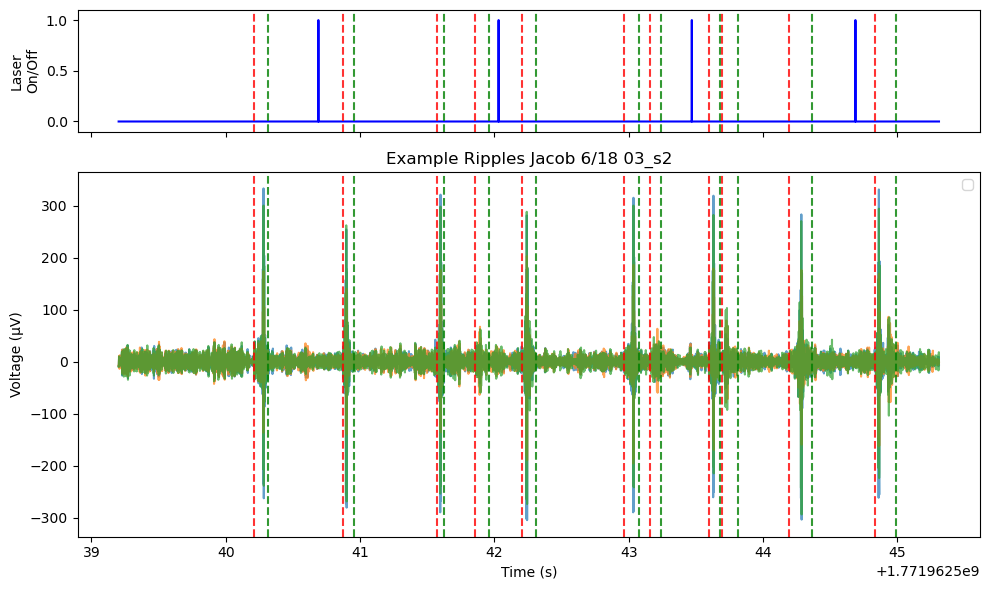

In [75]:
import matplotlib.pyplot as plt
import numpy as np

ripple_band_df = (lfp_band.LFPBandV1() & lfp_band_key).fetch1_dataframe()

window = 3
i = 150
ripple_start = ripple_times.iloc[i].start_time
ripple_end = ripple_times.iloc[i].end_time

# --- Extract ripple band window ---
time_window = ripple_band_df.loc[ripple_start - window : ripple_end + window]

# Find all ripples within the time window
window_start = ripple_start - window
window_end = ripple_end + window
ripples_in_window = ripple_times[
    (ripple_times['start_time'] >= window_start) &
    (ripple_times['end_time'] <= window_end)
]

# --- Extract timestamps in window ---
timestamps_in_window = df[
    (df['timestamp'] >= ripple_start - window) & (df['timestamp'] <= ripple_end + window)
]['timestamp']

# Only keep every other timestamp
timestamps_in_window = timestamps_in_window.iloc[::2]


# --- Make binary 0/1 trace ---
binary_trace = np.zeros(len(time_window.index))
# For each stim timestamp, set nearest index in time_window to 1
for ts in timestamps_in_window:
    idx = time_window.index.get_indexer([ts], method="nearest")[0]
    if idx != -1:  # Only update if a valid index was found
        binary_trace[idx] = 1

# --- Create subplots ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [1, 3]}
)

# Top subplot: binary opto stim trace
ax1.step(time_window.index, binary_trace, where="post", color="blue")
ax1.set_ylabel("Laser\nOn/Off")
ax1.set_ylim(-0.1, 1.1)

# Add all ripple markers to top subplot as well
for idx, ripple in ripples_in_window.iterrows():
    ax1.axvline(ripple['start_time'], color="r", linestyle="--", alpha=0.8)
    ax1.axvline(ripple['end_time'], color="g", linestyle="--", alpha=0.8)

# Bottom subplot: ripple band with markers
ax2.plot(time_window.index, time_window.iloc[:, ::15], alpha=0.7)

# Mark all ripple start and end times
for idx, ripple in ripples_in_window.iterrows():
    if idx == 0:  # Add label only to first ripple for legend
        ax2.axvline(ripple['start_time'], color="r", linestyle="--", alpha=0.8, label="Ripple Start")
        ax2.axvline(ripple['end_time'], color="g", linestyle="--", alpha=0.8, label="Ripple End")
    else:
        ax2.axvline(ripple['start_time'], color="r", linestyle="--", alpha=0.8)
        ax2.axvline(ripple['end_time'], color="g", linestyle="--", alpha=0.8)

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (µV)")
ax2.set_title("Example Ripples Jacob 6/18 03_s2")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

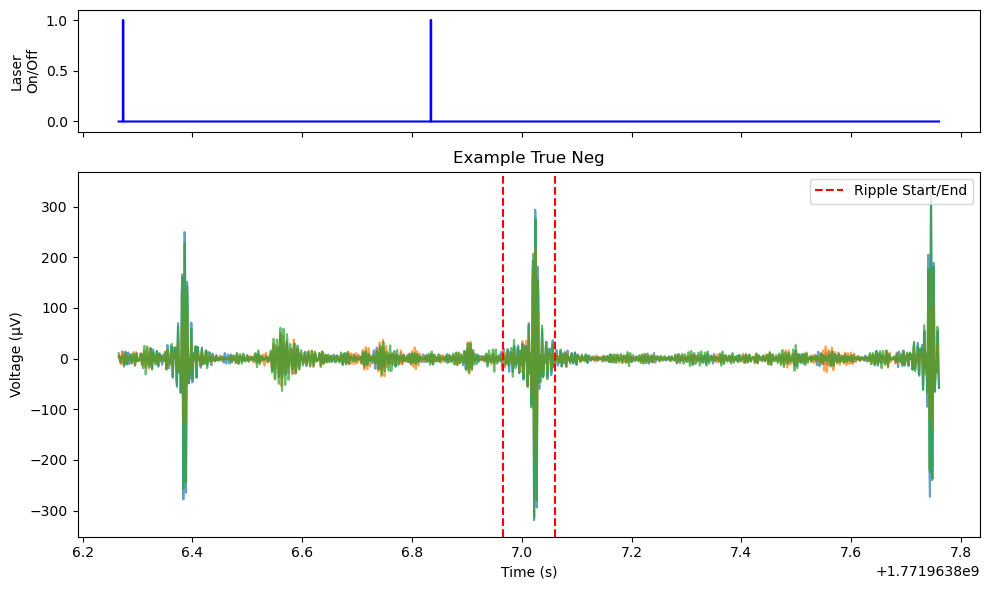

In [76]:
import matplotlib.pyplot as plt
import numpy as np

ripple_band_df = (lfp_band.LFPBandV1() & lfp_band_key).fetch1_dataframe()

window = 0.7
i = 2048
ripple_start = ripple_times.iloc[i].start_time
ripple_end = ripple_times.iloc[i].end_time

# --- Extract ripple band window ---
time_window = ripple_band_df.loc[ripple_start - window : ripple_end + window]

# --- Extract timestamps in window ---
timestamps_in_window = df[
    (df['timestamp'] >= ripple_start - window) & (df['timestamp'] <= ripple_end + window)
]['timestamp']

# Only keep every other timestamp
timestamps_in_window = timestamps_in_window.iloc[::2]


# --- Make binary 0/1 trace ---
binary_trace = np.zeros(len(time_window.index))
# For each stim timestamp, set nearest index in time_window to 1
for ts in timestamps_in_window:
    idx = time_window.index.get_indexer([ts], method="nearest")[0]
    if idx != -1:  # Only update if a valid index was found
        binary_trace[idx] = 1

# --- Create subplots ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [1, 3]}
)

# Top subplot: binary opto stim trace
ax1.step(time_window.index, binary_trace, where="post", color="blue")
ax1.set_ylabel("Laser\nOn/Off")
ax1.set_ylim(-0.1, 1.1)

# Bottom subplot: ripple band with markers
ax2.plot(time_window.index, time_window.iloc[:, ::15], alpha=0.7)

# # Mark ripple start and end
ax2.axvline(ripple_start, color="r", linestyle="--", label="Ripple Start/End")
ax2.axvline(ripple_end, color="r", linestyle="--")

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (µV)")
ax2.set_title("Example True Neg")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


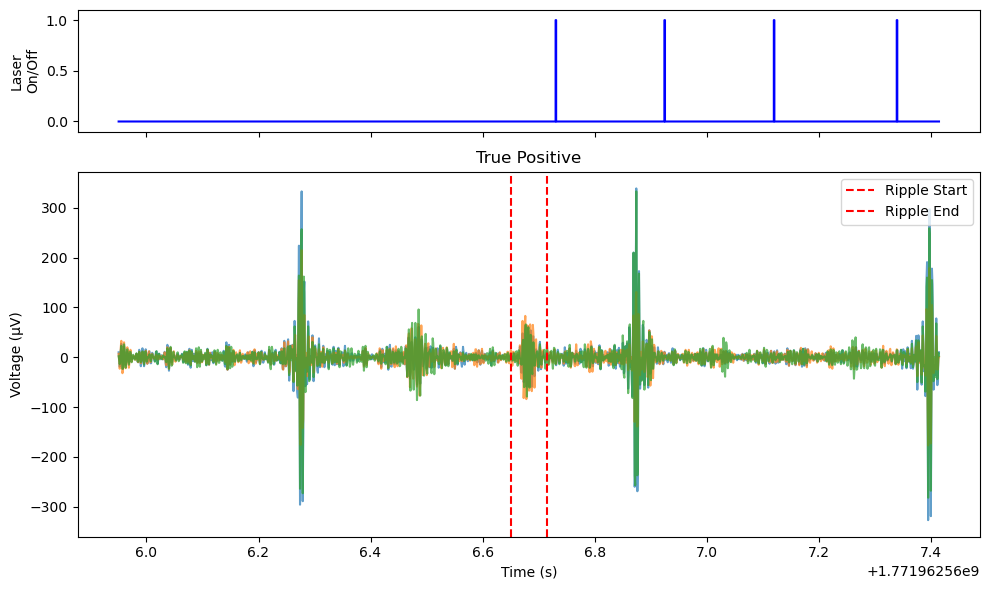

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# --- Load ripple band ---
ripple_band_df = (lfp_band.LFPBandV1() & lfp_band_key).fetch1_dataframe()

# --- Parameters ---
window = 0.7
i = 200

ripple_start = ripple_times.iloc[i].start_time
ripple_end = ripple_times.iloc[i].end_time

# --- Extract ripple window ---
time_window = ripple_band_df.loc[
    ripple_start - window : ripple_end + window
]

# --- Get stim timestamps in same window ---
timestamps_in_window = df[
    (df['timestamp'] >= ripple_start - window) &
    (df['timestamp'] <= ripple_end + window)
]['timestamp'].values

# --- Build binary stim trace ---
binary_trace = np.zeros(len(time_window.index))

for ts in timestamps_in_window:
    # find closest index in LFP time axis
    idx = np.argmin(np.abs(time_window.index.values - ts))
    binary_trace[idx] = 1

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 3]}
)

# --- Top: laser trace ---
ax1.step(time_window.index, binary_trace, where="post", color="blue")
ax1.set_ylabel("Laser\nOn/Off")
ax1.set_ylim(-0.1, 1.1)

# --- Bottom: ripple band ---
ax2.plot(time_window.index, time_window.iloc[:, ::15], alpha=0.7)

# --- Ripple boundaries ---
ax2.axvline(ripple_start, color="r", linestyle="--", label="Ripple Start")
ax2.axvline(ripple_end, color="r", linestyle="--", label="Ripple End")

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (µV)")
ax2.set_title("True Positive")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [78]:
import pandas as pd

# Assume your timestamps are in df['timestamps'] (in seconds)
timestamps = df['timestamp'].sort_values().reset_index(drop=True)

# Compute the difference between consecutive timestamps
dt = timestamps.diff()

# Consider a gap bigger than, e.g., 0.0025 s (2.5 ms) as a separation between bursts
gap_threshold = 0.004

# First timestamp of each burst: either the first one, or after a gap
first_of_bursts = timestamps[(dt.isna()) | (dt > gap_threshold)]

print(first_of_bursts)


0       1.771962e+09
1       1.771962e+09
2       1.771962e+09
3       1.771962e+09
4       1.771962e+09
            ...     
3196    1.771965e+09
3197    1.771965e+09
3198    1.771965e+09
3199    1.771965e+09
3200    1.771965e+09
Name: timestamp, Length: 3201, dtype: float64


In [79]:
ripple_times['mean_zscore']

id
0       1.519363
1       1.992888
2       1.588139
3       1.170341
4       1.916459
          ...   
3526    1.656756
3527    0.973631
3528    1.446211
3529    1.160846
3530    1.574119
Name: mean_zscore, Length: 3531, dtype: float64

In [80]:
ripple_times['mean_zscore']

# Compute the mean duration
mean_amplitude = ripple_times['mean_zscore'].mean()
mean_amplitude


1.8076075160249792

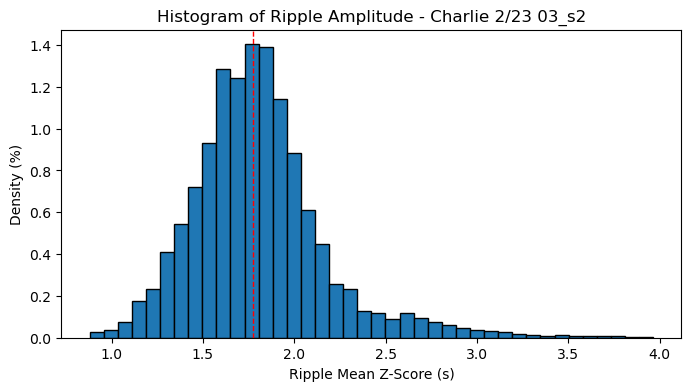

In [81]:
median = np.median(ripple_times['mean_zscore'])
# Plot histogram
plt.figure(figsize=(8,4))
plt.hist(ripple_times['mean_zscore'], bins = 40, edgecolor='black', density = True)
plt.xlabel("Ripple Mean Z-Score (s)")
plt.axvline(median, color = 'red', linestyle = 'dashed',linewidth = 1)
plt.ylabel("Density (%)")
plt.title("Histogram of Ripple Amplitude - Charlie 2/23 03_s2")
plt.show()

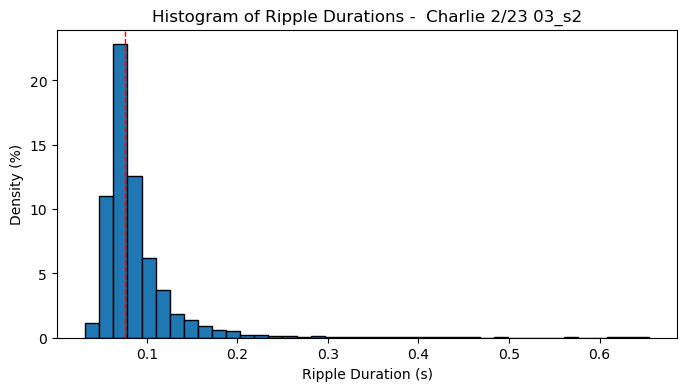

In [82]:

ripple_times['duration'] = ripple_times['end_time'] - ripple_times['start_time']
median = np.median(ripple_times['duration'])
# Plot histogram
plt.figure(figsize=(8,4))
plt.hist(ripple_times['duration'], bins = 40, edgecolor='black', density = True)
plt.xlabel("Ripple Duration (s)")
plt.axvline(median, color = 'red', linestyle = 'dashed',linewidth = 1)
plt.ylabel("Density (%)")
plt.title("Histogram of Ripple Durations -  Charlie 2/23 03_s2")
plt.show()


N ripples with pulse before: 2045
N ripples without pulse before: 1486
Mean duration with pulse before: 1.798 s
Mean duration without pulse before: 1.821 s
Mann-Whitney U test: stat=380354.0, p=0.7188


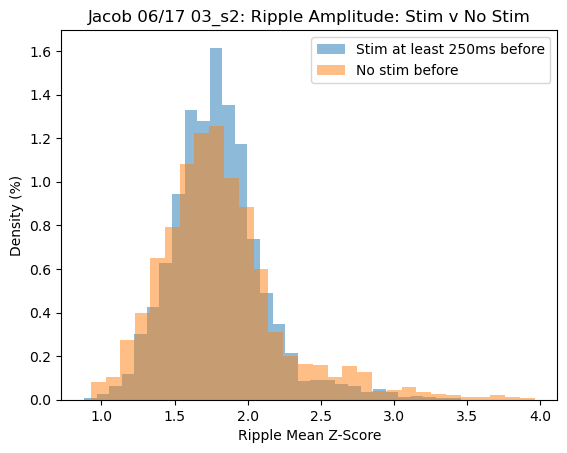

In [83]:
window = 0.25  # 250 ms before ripple

# --- Convert timestamps to numpy arrays ---
pulse_times = df['timestamp'].values
ripple_starts = ripple_times['start_time'].values
ripple_ends = ripple_times['end_time'].values

# --- Compute ripple duration ---
ripple_times['duration'] = ripple_times['end_time'] - ripple_times['start_time']

# --- Mark ripples with pulse BEFORE ---
pulse_before = ((pulse_times[:, None] >= (ripple_starts - window)) &
                (pulse_times[:, None] < ripple_starts)).any(axis=0)

# --- Add to dataframe ---
ripple_times['pulse_before'] = pulse_before

# --- Split durations ---
amp_with_pulse_before = ripple_times.loc[ripple_times['pulse_before'], 'mean_zscore']
amp_without_pulse_before = ripple_times.loc[~ripple_times['pulse_before'], 'mean_zscore']

# --- Print statistics ---
print(f"N ripples with pulse before: {len(amp_with_pulse_before)}")
print(f"N ripples without pulse before: {len(amp_without_pulse_before)}")
print(f"Mean duration with pulse before: {amp_with_pulse_before.mean():.3f} s")
print(f"Mean duration without pulse before: {amp_without_pulse_before.mean():.3f} s")

# --- Statistical test ---
# stat, p_value = mannwhitneyu(amp_with_pulse_before, amp_without_pulse_before, alternative='two-sided')
print(f"Mann-Whitney U test: stat={stat}, p={p_value:.4f}")

# --- Plot distributions ---
plt.hist(amp_with_pulse_before, bins=30, alpha=0.5, label='Stim at least 250ms before', density = True)
plt.hist(amp_without_pulse_before, bins=30, alpha=0.5, label='No stim before', density = True)
plt.xlabel("Ripple Mean Z-Score")
plt.ylabel("Density (%)")
plt.legend()
plt.title("Jacob 06/17 03_s2: Ripple Amplitude: Stim v No Stim")
plt.show()

Text(0.5, 0, 'SWR Number')

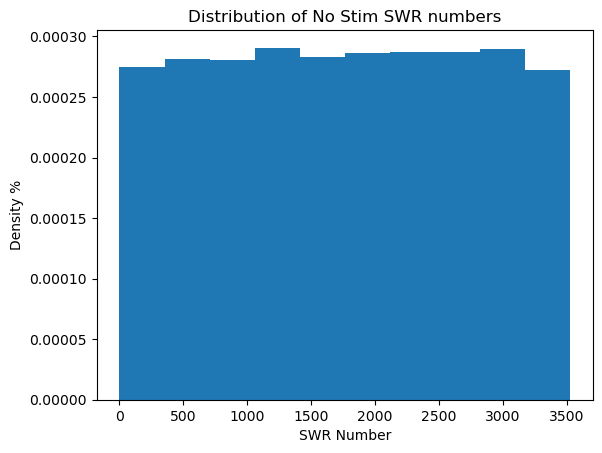

In [84]:
no_stim_ids = dur_without_stim.reset_index()['id']
plt.hist(no_stim_ids, density = True)
plt.title('Distribution of No Stim SWR numbers')
plt.ylabel('Density %')
plt.xlabel('SWR Number')

Text(0.5, 0, 'SWR Number')

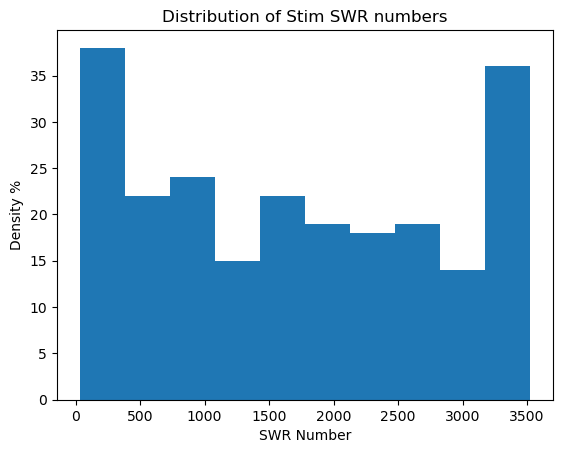

In [85]:
ids = dur_with_stim.reset_index()['id']
plt.hist(ids)
plt.title('Distribution of Stim SWR numbers')
plt.ylabel('Density %')
plt.xlabel('SWR Number')

N ripples with stim during: 207
N ripples without stim during: 3324
Mean duration with stim during: 0.130 s
Mean duration without stim during: 0.086 s
Mann-Whitney U test: stat=466588.0, p=0.0000


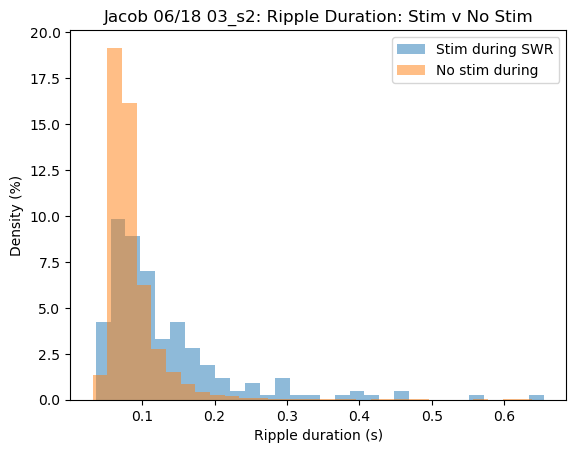

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --- Parameters ---
# Assume stim timestamps are in df['stim_timestamp']
stim_times = df['timestamp'].values # adjust if your stim column is named differently

# --- Convert ripple times ---
ripple_starts = ripple_times['start_time'].values
ripple_ends = ripple_times['end_time'].values

# --- Compute ripple duration ---
ripple_times['duration'] = ripple_times['end_time'] - ripple_times['start_time']

# --- Mark ripples with stim DURING ripple ---
stim_during = ((stim_times[:, None] >= ripple_starts) &
               (stim_times[:, None] <= ripple_ends)).any(axis=0)

ripple_times['stim_during'] = stim_during

# --- Split durations ---
dur_with_stim = ripple_times.loc[ripple_times['stim_during'], 'duration']
dur_without_stim = ripple_times.loc[~ripple_times['stim_during'], 'duration']

# --- Print statistics ---
print(f"N ripples with stim during: {len(dur_with_stim)}")
print(f"N ripples without stim during: {len(dur_without_stim)}")
print(f"Mean duration with stim during: {dur_with_stim.mean():.3f} s")
print(f"Mean duration without stim during: {dur_without_stim.mean():.3f} s")

# --- Statistical test ---
stat, p_value = mannwhitneyu(dur_with_stim, dur_without_stim, alternative='two-sided')
print(f"Mann-Whitney U test: stat={stat}, p={p_value:.4f}")

# --- Plot distributions ---
plt.hist(dur_with_stim, bins=30, alpha=0.5, label='Stim during SWR', density = True)
plt.hist(dur_without_stim, bins=30, alpha=0.5, label='No stim during', density = True)
plt.xlabel("Ripple duration (s)")
plt.ylabel("Density (%)")
plt.legend()
plt.title("Jacob 06/18 03_s2: Ripple Duration: Stim v No Stim")
plt.show()


In [87]:
ripple_times

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed,pulse_before,stim_during,stim_during_or_10ms_after
id,,,,,,,,,,,,,,,,,,,
0,1.771962e+09,1.771962e+09,0.087969,3.338891,1.519363,1.097073,3.967477,0.024825,0.135100,0.357446,0.959888,0.589643,0.959888,0.589643,0.725826,0.746011,False,False,False
1,1.771962e+09,1.771962e+09,0.060901,3.428816,1.992888,1.620669,4.584951,0.005475,0.123272,0.399770,2.676255,3.280816,3.280816,2.676255,3.082196,3.044299,False,False,False
2,1.771962e+09,1.771962e+09,0.086035,3.591680,1.588139,0.963636,4.423788,0.021022,0.138146,0.410300,0.124368,0.160842,0.160842,0.104677,0.113106,0.118364,False,False,False
3,1.771962e+09,1.771962e+09,0.147903,3.192727,1.170341,0.701932,3.873851,0.072858,0.174149,0.376563,3.196441,1.302038,3.196441,1.302038,2.177962,2.212899,True,False,False
4,1.771962e+09,1.771962e+09,0.081202,3.652040,1.916459,1.285347,4.420072,0.000591,0.157442,0.449403,0.286550,0.380612,0.380612,0.281521,0.300932,0.312380,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3526,1.771965e+09,1.771965e+09,0.164337,2.917561,1.656756,1.499201,4.809715,0.005329,0.273840,0.708319,1.251600,0.549871,1.251600,0.193128,0.538646,0.632723,False,False,False
3527,1.771965e+09,1.771965e+09,0.205904,2.197327,0.973631,0.760505,4.014757,0.038367,0.201377,0.321306,0.956219,0.302768,0.956219,0.302768,0.666839,0.650076,True,True,True
3528,1.771965e+09,1.771965e+09,0.211704,2.223592,1.446211,1.281564,3.858265,0.021237,0.307528,0.643393,2.130707,1.863898,3.157086,1.829374,2.682989,2.598260,False,False,False


N ripples with stim (during or ≤10ms after): 227
N ripples without stim: 3304
Mean duration with stim: 0.126 s
Mean duration without stim: 0.086 s
Mann-Whitney U test: stat=498073.5, p=0.0000


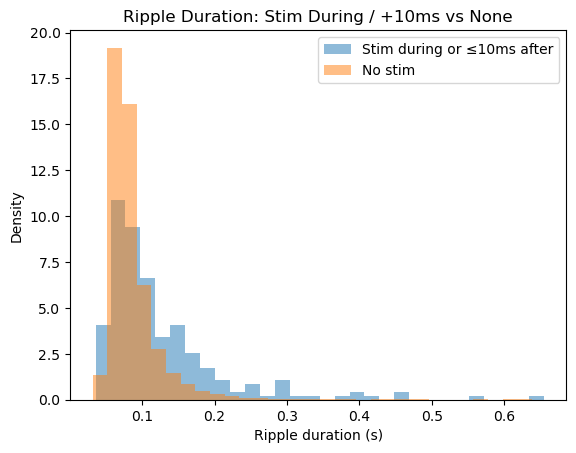

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --- Parameters ---
stim_times = df['timestamp'].values

# --- Convert ripple times ---
ripple_starts = ripple_times['start_time'].values
ripple_ends = ripple_times['end_time'].values

# --- Add 10 ms window ---
post_window = 0.010  # 10 ms in seconds

# --- Compute ripple duration ---
ripple_times['duration'] = ripple_times['end_time'] - ripple_times['start_time']

# --- Mark ripples with stim DURING or within 10 ms AFTER ---
stim_during_or_after = (
    (stim_times[:, None] >= ripple_starts) &
    (stim_times[:, None] <= (ripple_ends + post_window))
).any(axis=0)

ripple_times['stim_during_or_10ms_after'] = stim_during_or_after

# --- Split durations ---
dur_with_stim = ripple_times.loc[
    ripple_times['stim_during_or_10ms_after'], 'duration'
]
dur_without_stim = ripple_times.loc[
    ~ripple_times['stim_during_or_10ms_after'], 'duration'
]

# --- Print statistics ---
print(f"N ripples with stim (during or ≤10ms after): {len(dur_with_stim)}")
print(f"N ripples without stim: {len(dur_without_stim)}")
print(f"Mean duration with stim: {dur_with_stim.mean():.3f} s")
print(f"Mean duration without stim: {dur_without_stim.mean():.3f} s")

# --- Statistical test ---
stat, p_value = mannwhitneyu(dur_with_stim, dur_without_stim, alternative='two-sided')
print(f"Mann-Whitney U test: stat={stat}, p={p_value:.4f}")

# --- Plot distributions ---
plt.hist(dur_with_stim, bins=30, alpha=0.5, label='Stim during or ≤10ms after', density=True)
plt.hist(dur_without_stim, bins=30, alpha=0.5, label='No stim', density=True)
plt.xlabel("Ripple duration (s)")
plt.ylabel("Density")
plt.legend()
plt.title("Ripple Duration: Stim During / +10ms vs None")
plt.show()

N ripples with stim (during or ≤10ms after): 227
N ripples without stim: 3304
Mean duration with stim: 1.831 s
Mean duration without stim: 1.806 s
Mann-Whitney U test: stat=380354.0, p=0.7188


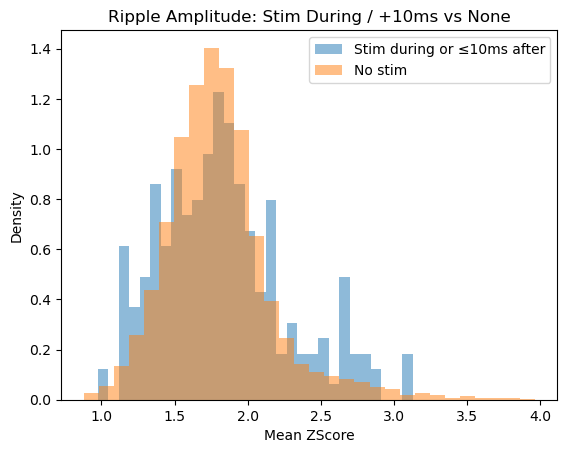

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --- Parameters ---
stim_times = df['timestamp'].values

# --- Convert ripple times ---
ripple_starts = ripple_times['start_time'].values
ripple_ends = ripple_times['end_time'].values

# --- Add 10 ms window ---
post_window = 0.010  # 10 ms in seconds

# --- Compute ripple duration ---
ripple_times['duration'] = ripple_times['end_time'] - ripple_times['start_time']

# --- Mark ripples with stim DURING or within 10 ms AFTER ---
stim_during_or_after = (
    (stim_times[:, None] >= ripple_starts) &
    (stim_times[:, None] <= (ripple_ends + post_window))
).any(axis=0)

ripple_times['stim_during_or_10ms_after'] = stim_during_or_after

# --- Split durations ---
dur_with_stim = ripple_times.loc[
    ripple_times['stim_during_or_10ms_after'], 'mean_zscore'
]
dur_without_stim = ripple_times.loc[
    ~ripple_times['stim_during_or_10ms_after'], 'mean_zscore'
]

# --- Print statistics ---
print(f"N ripples with stim (during or ≤10ms after): {len(dur_with_stim)}")
print(f"N ripples without stim: {len(dur_without_stim)}")
print(f"Mean duration with stim: {dur_with_stim.mean():.3f} s")
print(f"Mean duration without stim: {dur_without_stim.mean():.3f} s")

# --- Statistical test ---
stat, p_value = mannwhitneyu(dur_with_stim, dur_without_stim, alternative='two-sided')
print(f"Mann-Whitney U test: stat={stat}, p={p_value:.4f}")

# --- Plot distributions ---
plt.hist(dur_with_stim, bins=30, alpha=0.5, label='Stim during or ≤10ms after', density=True)
plt.hist(dur_without_stim, bins=30, alpha=0.5, label='No stim', density=True)
plt.xlabel("Mean ZScore")
plt.ylabel("Density")
plt.legend()
plt.title("Ripple Amplitude: Stim During / +10ms vs None")
plt.show()

In [90]:
len(stim_times)

3201

In [91]:
# --- Check if each stim falls inside ANY ripple ---
stim_in_ripple = ((stim_times[:, None] >= ripple_starts-0.010) &
                  (stim_times[:, None] <= ripple_ends)).any(axis=1)

# --- Count ---
n_stim_with_ripple = np.sum(stim_in_ripple)
n_stim_without_ripple = len(stim_times) - n_stim_with_ripple

print(f"N stims WITH ripple: {n_stim_with_ripple}")
print(f"N stims WITHOUT ripple: {n_stim_without_ripple}")

N stims WITH ripple: 244
N stims WITHOUT ripple: 2957


In [92]:
# ripple_power = (lfp_band.LFPBandV1() & {"lfp_merge_id": lfp_merge_id, "filter_name": filter_name}).compute_signal_power(
#     electrode_list=electrode_list
# )

In [93]:
import numpy as np

# --- Parameters ---
post_window = 0.010  # 10 ms

# --- Arrays ---
stim_times = df['timestamp'].values
ripple_starts = ripple_times['start_time'].values
ripple_ends = ripple_times['end_time'].values

# --- Ripples WITH stim (during or +10ms) ---
ripple_has_stim = (
    (stim_times[:, None] >= ripple_starts) &
    (stim_times[:, None] <= ripple_ends + post_window)
).any(axis=0)

# --- Stims WITH ripple ---
stim_in_ripple = (
    (stim_times[:, None] >= ripple_starts) &
    (stim_times[:, None] <= ripple_ends + post_window)
).any(axis=1)

# --- Counts ---
TP = np.sum(ripple_has_stim)                 # ripples with laser
FN = len(ripple_has_stim) - TP              # ripples without laser
FP = len(stim_times) - np.sum(stim_in_ripple)  # stims without ripple

print(f"TP (ripples with laser): {TP}")
print(f"FN (ripples without laser): {FN}")
print(f"FP (stims without ripple): {FP}")

TP (ripples with laser): 227
FN (ripples without laser): 3304
FP (stims without ripple): 2973


In [94]:
# --- Totals ---
n_ripples = len(ripple_has_stim)
n_stims = len(stim_times)

# --- Percentages ---
pct_ripples_with_stim = TP / n_ripples * 100
pct_ripples_without_stim = FN / n_ripples * 100

pct_stims_with_ripple = np.sum(stim_in_ripple) / n_stims * 100
pct_stims_without_ripple = FP / n_stims * 100

# --- Print nicely ---
print("\n--- Ripple-centered ---")
print(f"Ripples WITH laser: {TP} ({pct_ripples_with_stim:.2f}%)")
print(f"Ripples WITHOUT laser: {FN} ({pct_ripples_without_stim:.2f}%)")

print("\n--- Stim-centered ---")
print(f"Stims WITH ripple: {np.sum(stim_in_ripple)} ({pct_stims_with_ripple:.2f}%)")
print(f"Stims WITHOUT ripple: {FP} ({pct_stims_without_ripple:.2f}%)")


--- Ripple-centered ---
Ripples WITH laser: 227 (6.43%)
Ripples WITHOUT laser: 3304 (93.57%)

--- Stim-centered ---
Stims WITH ripple: 228 (7.12%)
Stims WITHOUT ripple: 2973 (92.88%)


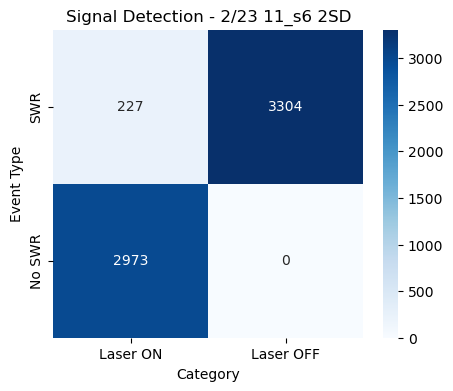

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Custom matrix (no TN)
cm = np.array([
    [TP, FN],
    [FP, 0]
])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Laser ON', 'Laser OFF'],
            yticklabels=['SWR', 'No SWR'])

plt.title("Signal Detection - 2/23 11_s6 2SD")
plt.xlabel("Category")
plt.ylabel("Event Type")
plt.show()

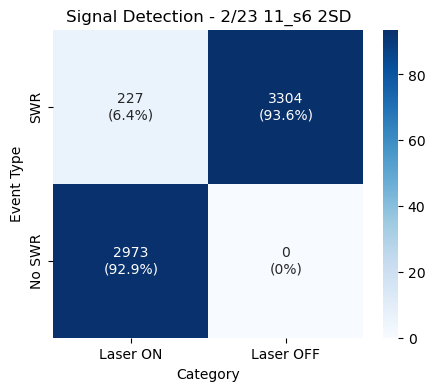

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Totals ---
n_ripples = TP + FN
n_stims = FP + np.sum(stim_in_ripple)

# --- Convert to percentages (row-wise) ---
cm_pct = np.array([
    [TP / n_ripples * 100, FN / n_ripples * 100],
    [FP / n_stims * 100, 0]
])

# --- Labels with percentages + counts ---
labels = np.array([
    [f"{TP}\n({cm_pct[0,0]:.1f}%)", f"{FN}\n({cm_pct[0,1]:.1f}%)"],
    [f"{FP}\n({cm_pct[1,0]:.1f}%)", "0\n(0%)"]
])

# --- Plot ---
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Laser ON', 'Laser OFF'],
            yticklabels=['SWR', 'No SWR'])

plt.title("Signal Detection - 2/23 11_s6 2SD")
plt.xlabel("Category")
plt.ylabel("Event Type")
plt.show()

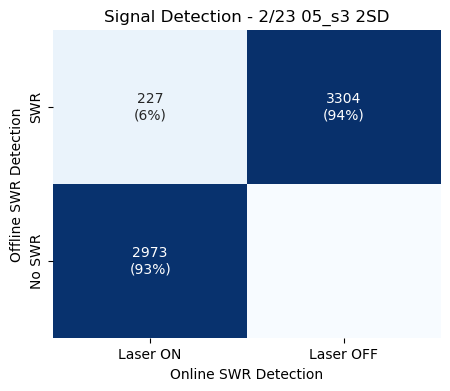

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Totals ---
n_ripples = TP + FN
n_stims = FP + np.sum(stim_in_ripple)

# --- Percentages (rounded) ---
cm_pct = np.array([
    [round(TP / n_ripples * 100), round(FN / n_ripples * 100)],
    [round(FP / n_stims * 100), 0]
])

# --- Labels (leave bottom-right blank) ---
labels = np.array([
    [f"{TP}\n({cm_pct[0,0]}%)", f"{FN}\n({cm_pct[0,1]}%)"],
    [f"{FP}\n({cm_pct[1,0]}%)", ""]
])

# --- Plot ---
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Laser ON', 'Laser OFF'],
            yticklabels=['SWR', 'No SWR'],
            cbar=False)  # optional: cleaner look

plt.title("Signal Detection - 2/23 05_s3 2SD")
plt.xlabel("Online SWR Detection")
plt.ylabel("Offline SWR Detection")
plt.show()